In [16]:
import numpy as np
from matplotlib import pyplot as plt
import control as ctrl
from scipy.integrate import solve_ivp


# Actuador no lineal

Se tiene un sistema 
$$ G=\frac{1}{(s+1)^3} $$

actuado con una válvula con la siguiente característica

$$ v = u^4$$

y controlado por un PI.

Se desea ver la respuesta del sistema en distintos puntos de trabajo.

Como el sistema es no lineal vamos a necesitar integrar con solve_ivp. Para esto tenemos que expresar el modelo completo en variables de estado.

In [81]:
s = ctrl.tf('s')

# Planta
G = 1/(s+1)**3

# Controlador
Ti = 1
Kp = 0.15
C = Kp*(1+1/(Ti*s))

# Pero así como está no puedo simular porque tengo una no linealidad en el medio
Gss = ctrl.tf2ss(G)
A_ = np.asarray(Gss.A)
B_ = np.asarray(Gss.B).flatten()
C_ = np.asarray(Gss.C).flatten()
D_ = float(Gss.D[0][0])

# Armo el modelo a integrar con solve_ivp
# Se incluye la planta, el control y el actuador
def modelo(t, x):    
    xp = x[0:-1]
    xi = x[-1]

    # Salida
    y = C_ @ xp 

    # Error
    e = r - y

    # PI
    u = Kp * (e + xi/Ti)

    # Válvula
    v = u**4

    # Planta
    dx = A_ @ xp + B_ * v
    y = C_ @ xp 

    # Integrador del PI
    d_xi = e

    return np.append(dx, d_xi)

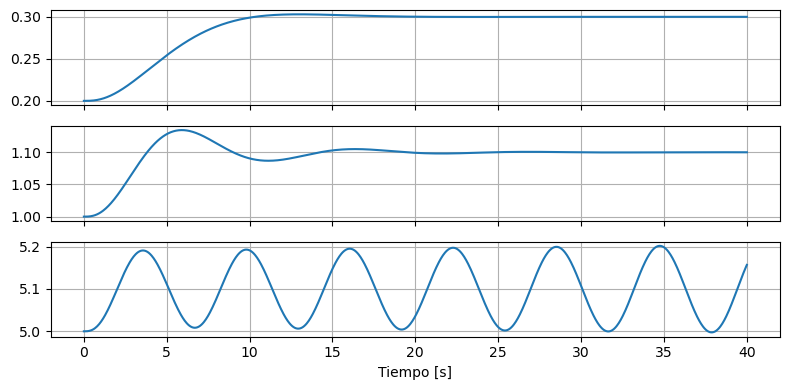

In [90]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 4))

for i,y0 in enumerate([0.2, 1.0, 5.0]):
    # Condición inicial
    u0 = y0**(1/4)
    xi0 = Ti*u0/Kp
    x0 = [0,0,y0,xi0]

    # Referencia
    r = y0+0.1

    # Simulación
    t = np.linspace(0, 40, 1000)
    sol = solve_ivp(
        modelo,
        [t[0], t[-1]],
        x0,
        t_eval=t
    )

    y = C_ @ sol.y[:-1, :]

    ax[i].plot(t, y)
    ax[i].grid()

ax[-1].set_xlabel('Tiempo [s]')
plt.tight_layout()
plt.show()